# 추출한 Pass Data 전처리 및 시각화

- Pass Data추출 방식 link : https://github.com/GunHeeJoe/EPV/blob/main/StatsBomb360%20pass%20data%20loading.ipynb

In [112]:
import numpy as np
import pandas as pd

from statsbombpy import sb

from mplsoccer import Pitch
import tqdm

In [45]:
df = pd.read_csv('./statsbomb360 data/pass_data',index_col=0)

/home/toc3/anaconda3/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3326: DtypeWarning: Columns (63,73,77,116,117,127) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


### 1. 원하는 컬럼만 뽑기

In [46]:
col = ['type_name','type','pass_type','result_name','pass_outcome','freeze_frame_x','location','pass_end_location','pass_angle','pass_length','player_id_x','player_name']

df = df[col]
df = df.rename(columns={'freeze_frame_x':'freeze_frame'})
df

,type_name,type,pass_type,result_name,pass_outcome,freeze_frame,location,pass_end_location,pass_angle,pass_length,player_id_x,player_name
0,pass,Pass,Recovery,fail,Incomplete,"[{'teammate': True, 'actor': False, 'keeper': ...","[43.8, 52.2]","[43.2, 52.2]",3.141593,0.600000,10167.0,Tatiana Pinto
1,pass,Pass,Recovery,fail,Incomplete,"[{'teammate': True, 'actor': False, 'keeper': ...","[76.9, 27.9]","[71.8, 30.7]",2.639502,5.818075,26093.0,Gun Nathalie Björn
2,freekick_short,Pass,Free Kick,success,NaN,"[{'teammate': True, 'actor': True, 'keeper': F...","[46.4, 60.5]","[32.7, 53.9]",-2.692650,15.206906,10140.0,Dolores Silva
3,pass,Pass,NaN,success,NaN,"[{'teammate': True, 'actor': True, 'keeper': F...","[34.1, 51.2]","[20.1, 39.1]",-2.428863,18.504324,32143.0,Diana Gomes
4,pass,Pass,NaN,fail,Incomplete,"[{'teammate': True, 'actor': True, 'keeper': T...","[22.9, 34.8]","[35.1, 13.0]",-1.060587,24.981594,10145.0,Patricia Sousa
...,...,...,...,...,...,...,...,...,...,...,...,...
123505,pass,Pass,NaN,success,NaN,"[{'teammate': True, 'actor': False, 'keeper': ...","[49.9, 57.9]","[54.8, 44.3]",-1.224980,14.455794,16509.0,Viktor Tsygankov
123506,pass,Pass,NaN,fail,Incomplete,"[{'teammate': True, 'actor': False, 'keeper': ...","[54.8, 44.3]","[43.4, 41.3]",-2.884269,11.788130,18881.0,Artem Besedin
123507,pass,Pass,Recovery,success,NaN,"[{'teammate': False, 'actor': False, 'keeper':...","[76.7, 38.8]","[84.7, 54.7]",1.104636,17.799158,30322.0,Darko Churlinov
123508,pass,Pass,NaN,offside,Pass Offside,"[{'teammate': True, 'actor': False, 'keeper': ...","[85.6, 70.6]","[96.4, 64.1]",-0.541780,12.605158,16509.0,Viktor Tsygankov


### 2. VAEP때 사용한데이터 & Events데이터의 Pass정의 살펴보기

- throw_in : 2946개라로 동일
- corner : 680+84 = 764로 동일
- goal_kick : 534개로 동일
- Free kick : 894 + 850 = 1744개로 동일

In [47]:
df['type_name'].value_counts()

pass                114896
throw_in              2946
cross                 2626
freekick_crossed       894
freekick_short         850
corner_crossed         680
goalkick               534
corner_short            84
Name: type_name, dtype: int64

In [48]:
df['type'].value_counts()

Pass    123510
Name: type, dtype: int64

In [49]:
df['pass_type'].value_counts()

Recovery        10167
Throw-in         2946
Free Kick        1744
Interception     1271
Corner            764
Goal Kick         534
Kick Off          342
Name: pass_type, dtype: int64

### i) VAEP때 사용한 pass데이터 중 Sub-type이 있는 pass데이터 살펴보기

- Recovery : loose ball이 되찾고 바로 원터치 패스
- Interception : Interception후 바로 패스
- Kick Off : 경기 시작 or 득점으로 인한 킥오프 패스

=> Kick Off패스는 의미있는 데이터가 아니므로 제외함

In [50]:
df[df['type_name'] == 'pass']['pass_type'].value_counts()

Recovery        10116
Interception     1270
Kick Off          342
Name: pass_type, dtype: int64

- 최종적으로 사용할 정의된 pass데이터

In [54]:
pass_df = df[(df['type_name'] == 'pass') & (df['pass_type'] != 'Kick Off')].reset_index().drop(columns=['index'])
pass_df

,type_name,type,pass_type,result_name,pass_outcome,freeze_frame,location,pass_end_location,pass_angle,pass_length,player_id_x,player_name
0,pass,Pass,Recovery,fail,Incomplete,"[{'teammate': True, 'actor': False, 'keeper': ...","[43.8, 52.2]","[43.2, 52.2]",3.141593,0.600000,10167.0,Tatiana Pinto
1,pass,Pass,Recovery,fail,Incomplete,"[{'teammate': True, 'actor': False, 'keeper': ...","[76.9, 27.9]","[71.8, 30.7]",2.639502,5.818075,26093.0,Gun Nathalie Björn
2,pass,Pass,NaN,success,NaN,"[{'teammate': True, 'actor': True, 'keeper': F...","[34.1, 51.2]","[20.1, 39.1]",-2.428863,18.504324,32143.0,Diana Gomes
3,pass,Pass,NaN,fail,Incomplete,"[{'teammate': True, 'actor': True, 'keeper': T...","[22.9, 34.8]","[35.1, 13.0]",-1.060587,24.981594,10145.0,Patricia Sousa
4,pass,Pass,NaN,success,NaN,"[{'teammate': True, 'actor': False, 'keeper': ...","[108.6, 35.8]","[110.0, 47.9]",1.455606,12.180722,10215.0,Fridolina Rolfö
...,...,...,...,...,...,...,...,...,...,...,...,...
114549,pass,Pass,Recovery,success,NaN,"[{'teammate': True, 'actor': False, 'keeper': ...","[30.2, 61.8]","[49.9, 57.9]",-0.195442,20.082330,31900.0,Oleksandr Karavaev
114550,pass,Pass,NaN,success,NaN,"[{'teammate': True, 'actor': False, 'keeper': ...","[49.9, 57.9]","[54.8, 44.3]",-1.224980,14.455794,16509.0,Viktor Tsygankov
114551,pass,Pass,NaN,fail,Incomplete,"[{'teammate': True, 'actor': False, 'keeper': ...","[54.8, 44.3]","[43.4, 41.3]",-2.884269,11.788130,18881.0,Artem Besedin
114552,pass,Pass,Recovery,success,NaN,"[{'teammate': False, 'actor': False, 'keeper':...","[76.7, 38.8]","[84.7, 54.7]",1.104636,17.799158,30322.0,Darko Churlinov


In [225]:
pass_df.to_csv('./statsbomb360 data/preprocess_pass_data')

### 3. Messi 선수의 패스 데이터를 시각화하기

In [88]:
messi_df = pass_df[pass_df.player_id_x == 5503].reset_index().drop(columns=['index'])
messi_df

,type_name,type,pass_type,result_name,pass_outcome,freeze_frame,location,pass_end_location,pass_angle,pass_length,player_id_x,player_name
0,pass,Pass,NaN,success,NaN,"[{'teammate': True, 'actor': False, 'keeper': ...","[65.9, 36.0]","[76.5, 21.6]",-0.936244,17.880716,5503.0,Lionel Messi
1,pass,Pass,NaN,success,NaN,"[{'teammate': True, 'actor': False, 'keeper': ...","[73.2, 47.1]","[89.5, 40.0]",-0.410800,17.779202,5503.0,Lionel Messi
2,pass,Pass,NaN,fail,Incomplete,"[{'teammate': True, 'actor': False, 'keeper': ...","[7.8, 21.6]","[11.1, 20.5]",-0.321751,3.478505,5503.0,Lionel Messi
3,pass,Pass,NaN,success,NaN,"[{'teammate': True, 'actor': False, 'keeper': ...","[62.9, 26.7]","[61.6, 11.3]",-1.655012,15.454773,5503.0,Lionel Messi
4,pass,Pass,NaN,success,NaN,"[{'teammate': True, 'actor': False, 'keeper': ...","[73.8, 17.2]","[74.6, 28.6]",1.500736,11.428036,5503.0,Lionel Messi
...,...,...,...,...,...,...,...,...,...,...,...,...
233,pass,Pass,NaN,success,NaN,"[{'teammate': True, 'actor': False, 'keeper': ...","[97.8, 65.8]","[90.8, 49.1]",-1.967711,18.107733,5503.0,Lionel Messi
234,pass,Pass,NaN,success,NaN,"[{'teammate': False, 'actor': False, 'keeper':...","[89.5, 37.1]","[100.5, 23.3]",-0.897825,17.647663,5503.0,Lionel Messi
235,pass,Pass,NaN,success,NaN,"[{'teammate': True, 'actor': False, 'keeper': ...","[87.0, 32.9]","[85.1, 23.1]",-1.762298,9.982485,5503.0,Lionel Messi
236,pass,Pass,NaN,success,NaN,"[{'teammate': True, 'actor': False, 'keeper': ...","[88.8, 56.2]","[89.8, 48.5]",-1.441649,7.764664,5503.0,Lionel Messi


In [117]:
messi_pass_location_df = pd.DataFrame(columns=['start_pass_x','start_pass_y','end_pass_x','end_pass_y'])

for i in tqdm.tqdm(range(len(messi_df))):
    start_x,start_y = map(float, messi_df.location[i].strip('[]').split(','))
    end_x,end_y = map(float, messi_df.pass_end_location[i].strip('[]').split(','))
    
    messi_pass_location_df.loc[i] = [start_x,start_y,end_x,end_y]

  0%|          | 0/238 [00:00<?, ?it/s]

100%|██████████| 238/238 [00:00<00:00, 976.22it/s]


In [118]:
messi_pass_location_df

,start_pass_x,start_pass_y,end_pass_x,end_pass_y
0,65.9,36.0,76.5,21.6
1,73.2,47.1,89.5,40.0
2,7.8,21.6,11.1,20.5
3,62.9,26.7,61.6,11.3
4,73.8,17.2,74.6,28.6
...,...,...,...,...
233,97.8,65.8,90.8,49.1
234,89.5,37.1,100.5,23.3
235,87.0,32.9,85.1,23.1
236,88.8,56.2,89.8,48.5


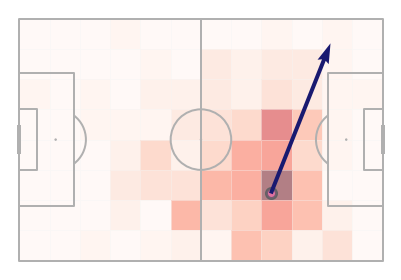

In [154]:
pitch = Pitch(line_zorder=2)
fig, ax = pitch.draw()
bin_statistic = pitch.bin_statistic(messi_pass_location_df['start_pass_x'], 
                                    messi_pass_location_df['start_pass_y'], bins=(12, 8))
bin_statistic_end = pitch.bin_statistic(messi_pass_location_df['end_pass_x'], 
                                        messi_pass_location_df['end_pass_y'], bins=(12, 8))

# let's get a mask for all passes that started in one grid cell and ended in another
mask_start = np.logical_and(bin_statistic['binnumber'][0] == 8,  # xs 5th box from left (zero indexed)
                            bin_statistic['binnumber'][1] == 5)  # ys 2nd from bottom (zero indexed)
mask_end = np.logical_and(bin_statistic_end['binnumber'][0] == 10,  # xs 6th box from left (zero indexed)
                          bin_statistic_end['binnumber'][1] == 0)  # ys 3rd box from bottom (zero indexed)
mask = np.logical_and(mask_start, mask_end)

# plot the passes that started in one grid cell and ended in another
pitch.scatter(messi_pass_location_df['start_pass_x'][mask], messi_pass_location_df['start_pass_y'][mask], 
              ax=ax, fc='hotpink',
              marker='o', s=100, ec='darkslategrey', lw=3, alpha=0.6, zorder=4)
pitch.arrows(messi_pass_location_df['start_pass_x'][mask], messi_pass_location_df['start_pass_y'][mask],
             messi_pass_location_df['end_pass_x'][mask],messi_pass_location_df['end_pass_y'][mask],
             ax=ax, zorder=10, color='midnightblue')

# plot all of the starting locations as a heatmap
pitch.heatmap(bin_statistic, ax=ax, cmap='Reds', edgecolor='#f9f9f9', alpha=0.5)

# plt.show()  # If you are using a Jupyter notebook you do not need this line

### 4. pixel 단위로 데이터 확보하기

In [155]:
bin_statistic = pitch.bin_statistic(messi_pass_location_df['start_pass_x'], 
                                    messi_pass_location_df['start_pass_y'], bins=(12, 8))
bin_statistic_end = pitch.bin_statistic(messi_pass_location_df['end_pass_x'], 
                                        messi_pass_location_df['end_pass_y'], bins=(12, 8))

In [157]:
bin_statistic.keys()

odict_keys(['statistic', 'x_grid', 'y_grid', 'cx', 'cy', 'binnumber', 'inside'])

i) 각 pixel별 패스 횟수

In [158]:
bin_statistic['statistic']

array([[ 0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  1.,  0.,  1.,  0.],
       [ 0.,  0.,  0.,  0.,  1.,  0.,  3.,  2.,  3.,  3.,  1.,  0.],
       [ 1.,  0.,  1.,  0.,  2.,  2.,  3.,  2.,  4.,  3.,  1.,  1.],
       [ 0.,  0.,  1.,  1.,  1.,  3.,  4.,  5., 14.,  7.,  1.,  0.],
       [ 0.,  0.,  0.,  2.,  5.,  2.,  5., 10., 11.,  5.,  1.,  0.],
       [ 0.,  0.,  0.,  3.,  4.,  4.,  9., 10., 19.,  8.,  0.,  0.],
       [ 0.,  0.,  0.,  2.,  0.,  9.,  4.,  6., 11.,  8.,  2.,  0.],
       [ 0.,  0.,  1.,  0.,  1.,  2.,  1.,  8.,  6.,  2.,  4.,  0.]])

ii) 각 pixel별 첫 위치(왼쪽 위)

In [163]:
for x,y in zip(bin_statistic['x_grid'],bin_statistic['y_grid']):
    print([(x[i],y[i]) for i in range(len(x))])

[(0.0, 0.0), (10.0, 0.0), (20.0, 0.0), (30.0, 0.0), (40.0, 0.0), (50.0, 0.0), (60.0, 0.0), (70.0, 0.0), (80.0, 0.0), (90.0, 0.0), (100.0, 0.0), (110.0, 0.0), (120.0, 0.0)]
[(0.0, 10.0), (10.0, 10.0), (20.0, 10.0), (30.0, 10.0), (40.0, 10.0), (50.0, 10.0), (60.0, 10.0), (70.0, 10.0), (80.0, 10.0), (90.0, 10.0), (100.0, 10.0), (110.0, 10.0), (120.0, 10.0)]
[(0.0, 20.0), (10.0, 20.0), (20.0, 20.0), (30.0, 20.0), (40.0, 20.0), (50.0, 20.0), (60.0, 20.0), (70.0, 20.0), (80.0, 20.0), (90.0, 20.0), (100.0, 20.0), (110.0, 20.0), (120.0, 20.0)]
[(0.0, 30.0), (10.0, 30.0), (20.0, 30.0), (30.0, 30.0), (40.0, 30.0), (50.0, 30.0), (60.0, 30.0), (70.0, 30.0), (80.0, 30.0), (90.0, 30.0), (100.0, 30.0), (110.0, 30.0), (120.0, 30.0)]
[(0.0, 40.0), (10.0, 40.0), (20.0, 40.0), (30.0, 40.0), (40.0, 40.0), (50.0, 40.0), (60.0, 40.0), (70.0, 40.0), (80.0, 40.0), (90.0, 40.0), (100.0, 40.0), (110.0, 40.0), (120.0, 40.0)]
[(0.0, 50.0), (10.0, 50.0), (20.0, 50.0), (30.0, 50.0), (40.0, 50.0), (50.0, 50.0), (60.

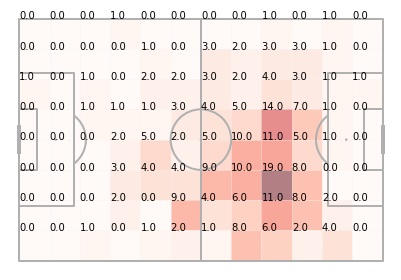

In [184]:

pitch = Pitch(line_zorder=2)
fig, ax = pitch.draw()
bin_statistic = pitch.bin_statistic(messi_pass_location_df['start_pass_x'], 
                                    messi_pass_location_df['start_pass_y'], bins=(12, 8))
bin_statistic_end = pitch.bin_statistic(messi_pass_location_df['end_pass_x'], 
                                        messi_pass_location_df['end_pass_y'], bins=(12, 8))


# plot the passes that started in one grid cell and ended in another
# pitch.scatter(messi_pass_location_df['start_pass_x'], messi_pass_location_df['start_pass_y'],
#               ax=ax, fc='hotpink',
#               marker='o', s=100, ec='darkslategrey', lw=3, alpha=0.6, zorder=4)

# plot all of the starting locations as a heatmap
pitch.heatmap(bin_statistic, ax=ax, cmap='Reds', edgecolor='#f9f9f9', alpha=0.5)

# plt.show()  # If you are using a Jupyter notebook you do not need this line

for i in range(8):
    for j in range(12):
        ax.text(x=bin_statistic['x_grid'][i][j],
                y=bin_statistic['y_grid'][i][j],
                #각 pixel 첫 위치에 messi패스 횟수
                s=bin_statistic['statistic'][i][j])
# for x,y in zip(bin_statistic['x_grid'],bin_statistic['y_grid']):
#     print([(x[i],y[i]) for i in range(len(x))])

iii) 각 pixel별 중앙 위치

In [165]:
for x,y in zip(bin_statistic['cx'],bin_statistic['cy']):
    print([(x[i],y[i]) for i in range(len(x))])

[(5.0, 5.0), (15.0, 5.0), (25.0, 5.0), (35.0, 5.0), (45.0, 5.0), (55.0, 5.0), (65.0, 5.0), (75.0, 5.0), (85.0, 5.0), (95.0, 5.0), (105.0, 5.0), (115.0, 5.0)]
[(5.0, 15.0), (15.0, 15.0), (25.0, 15.0), (35.0, 15.0), (45.0, 15.0), (55.0, 15.0), (65.0, 15.0), (75.0, 15.0), (85.0, 15.0), (95.0, 15.0), (105.0, 15.0), (115.0, 15.0)]
[(5.0, 25.0), (15.0, 25.0), (25.0, 25.0), (35.0, 25.0), (45.0, 25.0), (55.0, 25.0), (65.0, 25.0), (75.0, 25.0), (85.0, 25.0), (95.0, 25.0), (105.0, 25.0), (115.0, 25.0)]
[(5.0, 35.0), (15.0, 35.0), (25.0, 35.0), (35.0, 35.0), (45.0, 35.0), (55.0, 35.0), (65.0, 35.0), (75.0, 35.0), (85.0, 35.0), (95.0, 35.0), (105.0, 35.0), (115.0, 35.0)]
[(5.0, 45.0), (15.0, 45.0), (25.0, 45.0), (35.0, 45.0), (45.0, 45.0), (55.0, 45.0), (65.0, 45.0), (75.0, 45.0), (85.0, 45.0), (95.0, 45.0), (105.0, 45.0), (115.0, 45.0)]
[(5.0, 55.0), (15.0, 55.0), (25.0, 55.0), (35.0, 55.0), (45.0, 55.0), (55.0, 55.0), (65.0, 55.0), (75.0, 55.0), (85.0, 55.0), (95.0, 55.0), (105.0, 55.0), (115.0,

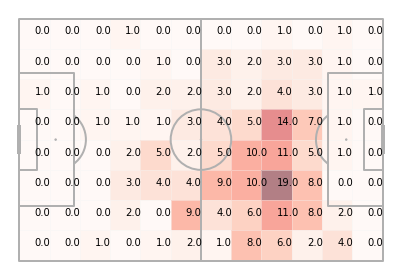

In [185]:

pitch = Pitch(line_zorder=2)
fig, ax = pitch.draw()
bin_statistic = pitch.bin_statistic(messi_pass_location_df['start_pass_x'], 
                                    messi_pass_location_df['start_pass_y'], bins=(12, 8))
bin_statistic_end = pitch.bin_statistic(messi_pass_location_df['end_pass_x'], 
                                        messi_pass_location_df['end_pass_y'], bins=(12, 8))


# plot the passes that started in one grid cell and ended in another
# pitch.scatter(messi_pass_location_df['start_pass_x'], messi_pass_location_df['start_pass_y'],
#               ax=ax, fc='hotpink',
#               marker='o', s=100, ec='darkslategrey', lw=3, alpha=0.6, zorder=4)

# plot all of the starting locations as a heatmap
pitch.heatmap(bin_statistic, ax=ax, cmap='Reds', edgecolor='#f9f9f9', alpha=0.5)

# plt.show()  # If you are using a Jupyter notebook you do not need this line

for i in range(8):
    for j in range(12):
        ax.text(x=bin_statistic['cx'][i][j],
                y=bin_statistic['cy'][i][j],
                #각 pixel 중앙 위치에 messi패스 횟수
                s=bin_statistic['statistic'][i][j])
# for x,y in zip(bin_statistic['x_grid'],bin_statistic['y_grid']):
#     print([(x[i],y[i]) for i in range(len(x))])

iv) 각 pixel별 bin번호

In [199]:
bin_statistic['binnumber']

array([[ 6,  7,  0,  6,  7,  5,  9,  9,  9,  7,  9,  8,  9,  6,  8,  8,
         6,  7,  5,  9,  8,  9,  7,  8,  8,  6,  9,  7,  8,  9, 10,  8,
         2,  6,  5,  8,  8,  4,  5,  7,  6,  7, 10,  9,  8,  4,  8,  9,
         8, 10,  5,  6,  7,  5,  6,  8,  9,  6,  6, 10,  3,  2,  6,  6,
         4,  3,  5,  7,  9,  8,  8,  9, 10,  7,  8,  7, 10,  9, 10,  9,
         7,  9,  6,  8,  3,  8,  5,  8,  4,  6,  5,  4,  3,  8,  7,  8,
         7,  6,  7,  5,  8,  8,  7,  8,  7,  7,  7,  9,  7, 10,  5,  7,
         7,  8,  9,  8,  9,  8,  8, 10,  9,  8,  8,  9,  9,  7,  9,  8,
         8,  8,  9,  8,  5,  8,  6,  8,  9,  8,  9,  7,  5,  7,  7,  8,
         8,  8,  5,  5,  7,  5,  5,  5,  7,  6,  9,  8,  8,  8,  7,  8,
         8,  8,  6,  6,  8,  8, 11,  8,  7,  8,  8,  8,  7,  8,  7,  7,
         8,  8,  7,  2,  4,  4,  3,  7, 10,  4,  3,  4,  4,  9,  9,  3,
         4,  6,  8,  8,  5,  6,  6,  7,  6,  8,  4,  7,  8,  9,  3,  9,
         4,  5,  4,  8,  7,  8,  5,  7,  9,  9,  9,  6,  5,  3, 

In [203]:
import collections

lst = []
for x,y in zip(bin_statistic['binnumber'][0],bin_statistic['binnumber'][1]):
    lst.append((x,y))
    
print(collections.Counter(lst))

Counter({(8, 5): 19, (8, 3): 14, (8, 6): 11, (8, 4): 11, (7, 4): 10, (7, 5): 10, (6, 5): 9, (5, 6): 9, (9, 5): 8, (9, 6): 8, (7, 7): 8, (9, 3): 7, (8, 7): 6, (7, 6): 6, (7, 3): 5, (6, 4): 5, (9, 4): 5, (4, 4): 5, (6, 3): 4, (5, 5): 4, (4, 5): 4, (6, 6): 4, (10, 7): 4, (8, 2): 4, (6, 2): 3, (5, 3): 3, (9, 1): 3, (6, 1): 3, (8, 1): 3, (9, 2): 3, (3, 5): 3, (7, 1): 2, (5, 7): 2, (9, 7): 2, (5, 2): 2, (4, 2): 2, (10, 6): 2, (5, 4): 2, (3, 6): 2, (3, 4): 2, (7, 2): 2, (0, 2): 1, (10, 0): 1, (2, 2): 1, (10, 2): 1, (8, 0): 1, (2, 7): 1, (4, 1): 1, (3, 0): 1, (10, 3): 1, (10, 4): 1, (10, 1): 1, (11, 2): 1, (2, 3): 1, (4, 3): 1, (6, 7): 1, (4, 7): 1, (3, 3): 1})


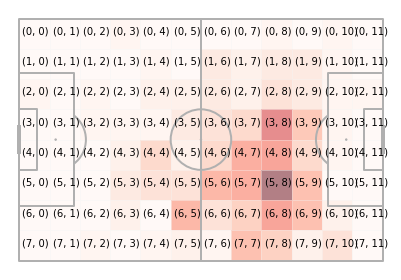

In [224]:
pitch = Pitch(line_zorder=2)
fig, ax = pitch.draw()
bin_statistic = pitch.bin_statistic(messi_pass_location_df['start_pass_x'], 
                                    messi_pass_location_df['start_pass_y'], bins=(12, 8))
bin_statistic_end = pitch.bin_statistic(messi_pass_location_df['end_pass_x'], 
                                        messi_pass_location_df['end_pass_y'], bins=(12, 8))


# plot the passes that started in one grid cell and ended in another
# pitch.scatter(messi_pass_location_df['start_pass_x'], messi_pass_location_df['start_pass_y'],
#               ax=ax, fc='hotpink',
#               marker='o', s=100, ec='darkslategrey', lw=3, alpha=0.6, zorder=4)

# plot all of the starting locations as a heatmap
pitch.heatmap(bin_statistic, ax=ax, cmap='Reds', edgecolor='#f9f9f9', alpha=0.5)

# plt.show()  # If you are using a Jupyter notebook you do not need this line

for i in range(8):
    for j in range(12):
        key = (j+1, i+1)
        ax.text(x=bin_statistic['cx'][i][j]-4,
                y=bin_statistic['cy'][i][j],
                #각 pixel 중앙에 pixel number
                s=(i,j))
# for x,y in zip(bin_statistic['x_grid'],bin_statistic['y_grid']):
#     print([(x[i],y[i]) for i in range(len(x))])

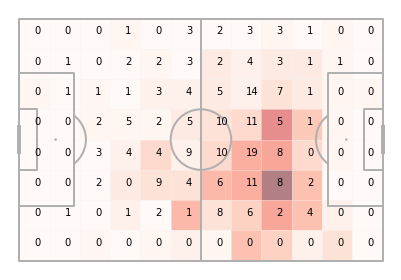

In [223]:
pitch = Pitch(line_zorder=2)
fig, ax = pitch.draw()
bin_statistic = pitch.bin_statistic(messi_pass_location_df['start_pass_x'], 
                                    messi_pass_location_df['start_pass_y'], bins=(12, 8))
bin_statistic_end = pitch.bin_statistic(messi_pass_location_df['end_pass_x'], 
                                        messi_pass_location_df['end_pass_y'], bins=(12, 8))


# plot the passes that started in one grid cell and ended in another
# pitch.scatter(messi_pass_location_df['start_pass_x'], messi_pass_location_df['start_pass_y'],
#               ax=ax, fc='hotpink',
#               marker='o', s=100, ec='darkslategrey', lw=3, alpha=0.6, zorder=4)

# plot all of the starting locations as a heatmap
pitch.heatmap(bin_statistic, ax=ax, cmap='Reds', edgecolor='#f9f9f9', alpha=0.5)

# plt.show()  # If you are using a Jupyter notebook you do not need this line

for i in range(8):
    for j in range(12):
        key = (j+1, i+1)
        ax.text(x=bin_statistic['cx'][i][j],
                y=bin_statistic['cy'][i][j],
                s=collections.Counter(lst)[key])
# for x,y in zip(bin_statistic['x_grid'],bin_statistic['y_grid']):
#     print([(x[i],y[i]) for i in range(len(x))])